# Lecture A03: Geocentric Models

Companion notebook for [[Lecture A03 - Geocentric Models]]. Prerequisites: [[A01|A01]], [[A02|A02]].

**Part 1** — Lecture walkthrough: generative model, model notation, prior predictive simulation, vague vs weakly informative priors, Bayesian updating, quadratic approximation

**Part 2** — Applied exercises with Slovenian data: area-price regression, forensic duration-anomaly model, domain-informed priors, salary-price regression, full posterior vs point estimate predictions

**Convention:** 89% credible intervals (McElreath default).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 150,
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

C_PRIOR = "#9ca3af"
C_POSTERIOR = "#2563eb"
C_LIKELIHOOD = "#dc2626"
C_DATA = "#059669"
C_ACCENT = "#d97706"
C_POINT = "#111827"

DATA_DIR = Path("../data")
CI_LEVEL = 0.89
N_SAMPLES = 10_000

---

# Part 1: Lecture Walkthrough

## 1. The Generative Model

**DAG:** $H \rightarrow W \leftarrow U$

Weight is a function of height and unobserved causes. The static generative model:

$$W = \beta H + U, \quad U \sim \text{Normal}(0, \sigma)$$

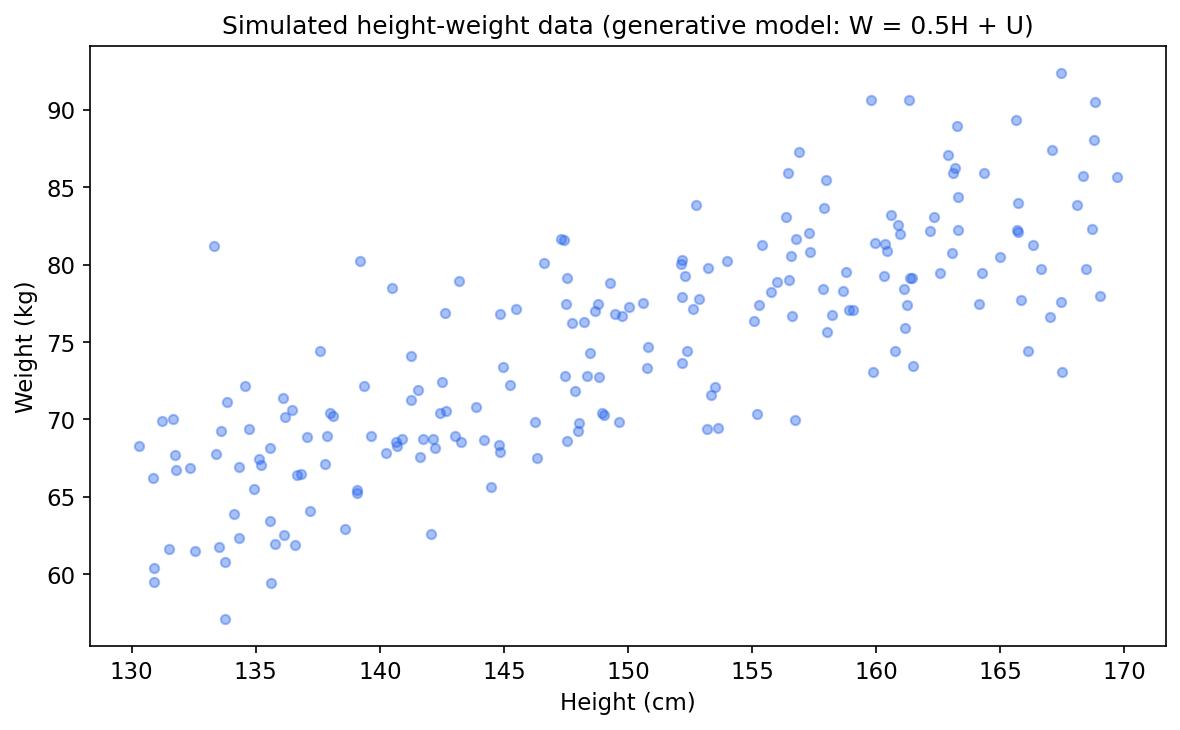

In [2]:
def sim_weight(
    h: np.ndarray,
    beta: float = 0.5,
    sd: float = 5.0,
    seed: int = SEED,
) -> np.ndarray:
    """Simulate weights from heights using a linear generative model.

    Args:
        h: Array of heights (cm).
        beta: Proportionality constant (kg per cm).
        sd: Standard deviation of unobserved causes.
        seed: Random seed.

    Returns:
        Array of simulated weights (kg).
    """
    rng = np.random.default_rng(seed)
    u = rng.normal(0, sd, size=len(h))
    return beta * h + u


# Generate synthetic population
rng_sim = np.random.default_rng(SEED)
n_sim = 200
h_sim = rng_sim.uniform(130, 170, size=n_sim)
w_sim = sim_weight(h_sim, beta=0.5, sd=5.0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(h_sim, w_sim, alpha=0.4, s=20, color=C_POSTERIOR)
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Weight (kg)")
ax.set_title("Simulated height-weight data (generative model: W = 0.5H + U)")
plt.tight_layout()
plt.show()

## 2. Model Notation and Log Posterior

The statistical model:

$$W_i \sim \text{Normal}(\mu_i, \sigma)$$
$$\mu_i = \alpha + \beta H_i$$
$$\alpha \sim \text{Normal}(0, 10)$$
$$\beta \sim \text{Uniform}(0, 1)$$
$$\sigma \sim \text{Uniform}(0, 10)$$

The garden of forking data now has three dimensions: $(\alpha, \beta, \sigma)$. For each combination, the number of ways to produce the observed data is the product of normal densities (the likelihood).

In [3]:
def log_posterior(
    alpha: float,
    beta: float,
    sigma: float,
    heights: np.ndarray,
    weights: np.ndarray,
) -> float:
    """Compute unnormalized log posterior for the linear regression model.

    Args:
        alpha: Intercept.
        beta: Slope.
        sigma: Standard deviation (must be positive).
        heights: Observed heights.
        weights: Observed weights.

    Returns:
        Log posterior (unnormalized).
    """
    if sigma <= 0:
        return -np.inf

    mu = alpha + beta * heights
    ll = np.sum(stats.norm.logpdf(weights, loc=mu, scale=sigma))
    lp_alpha = stats.norm.logpdf(alpha, loc=0, scale=10)
    lp_beta = stats.uniform.logpdf(beta, loc=0, scale=1)
    lp_sigma = stats.uniform.logpdf(sigma, loc=0, scale=10)

    return ll + lp_alpha + lp_beta + lp_sigma


# Test: evaluate at true parameters vs wrong parameters
lp_true = log_posterior(-10, 0.5, 5.0, h_sim, w_sim)
lp_wrong = log_posterior(50, 0.1, 20.0, h_sim, w_sim)
print(f"Log posterior at true params:  {lp_true:.1f}")
print(f"Log posterior at wrong params: {lp_wrong:.1f}")
print(f"True params are exp({lp_true - lp_wrong:.0f}) times more plausible")

Log posterior at true params:  -977.0
Log posterior at wrong params: -inf
True params are exp(inf) times more plausible


## 3. Prior Predictive Simulation

Sample $(\alpha, \beta)$ from the priors. Each pair defines a line. The spread of lines shows what the model believes *before* seeing data.

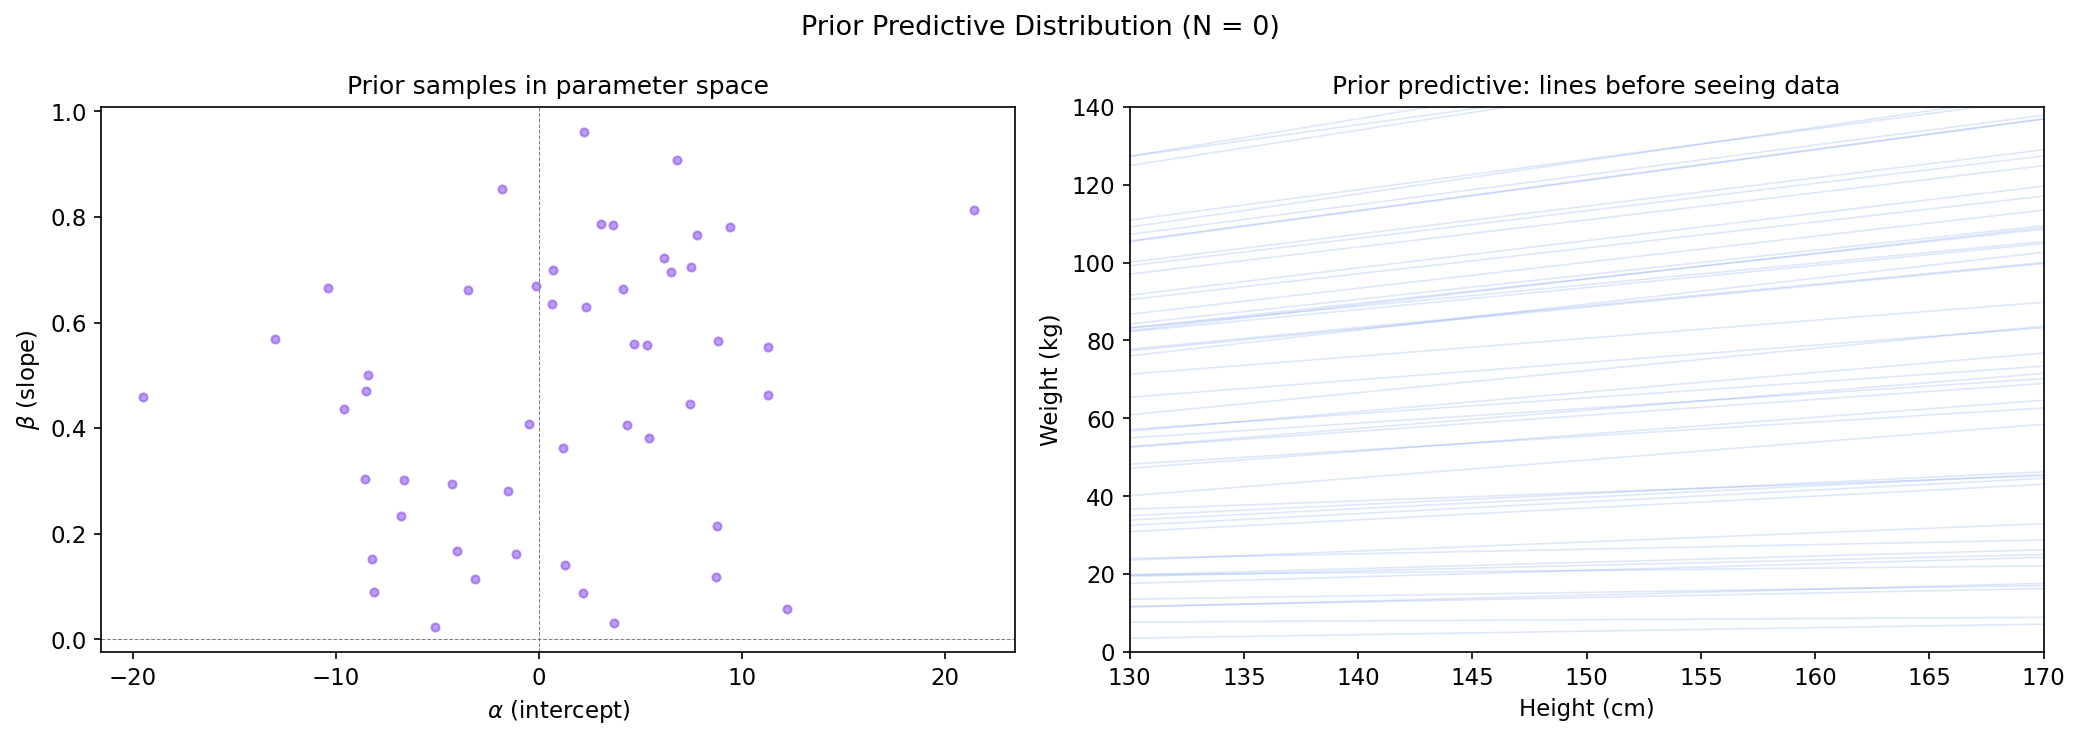

In [4]:
def prior_predictive_regression(n_lines: int = 50, seed: int = SEED) -> None:
    """Visualize lines implied by the prior."""
    rng = np.random.default_rng(seed)
    alphas = rng.normal(0, 10, size=n_lines)
    betas = rng.uniform(0, 1, size=n_lines)
    h_range = np.array([130, 170])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(alphas, betas, alpha=0.5, s=15, color="#7c3aed")
    axes[0].set_xlabel(r"$\alpha$ (intercept)")
    axes[0].set_ylabel(r"$\beta$ (slope)")
    axes[0].set_title("Prior samples in parameter space")
    axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")
    axes[0].axvline(0, color="gray", linewidth=0.5, linestyle="--")

    for a, b in zip(alphas, betas):
        axes[1].plot(h_range, a + b * h_range, alpha=0.15, color=C_POSTERIOR, linewidth=0.8)
    axes[1].set_xlabel("Height (cm)")
    axes[1].set_ylabel("Weight (kg)")
    axes[1].set_title("Prior predictive: lines before seeing data")
    axes[1].set_xlim(130, 170)
    axes[1].set_ylim(0, 140)

    plt.suptitle("Prior Predictive Distribution (N = 0)", fontsize=13)
    plt.tight_layout()
    plt.show()

prior_predictive_regression()

## 4. Vague vs Weakly Informative Priors

Vague priors allow absurd relationships (negative weights, slopes of 10 kg/cm). Weakly informative priors restrict to physically plausible relationships while leaving room for the data to speak.

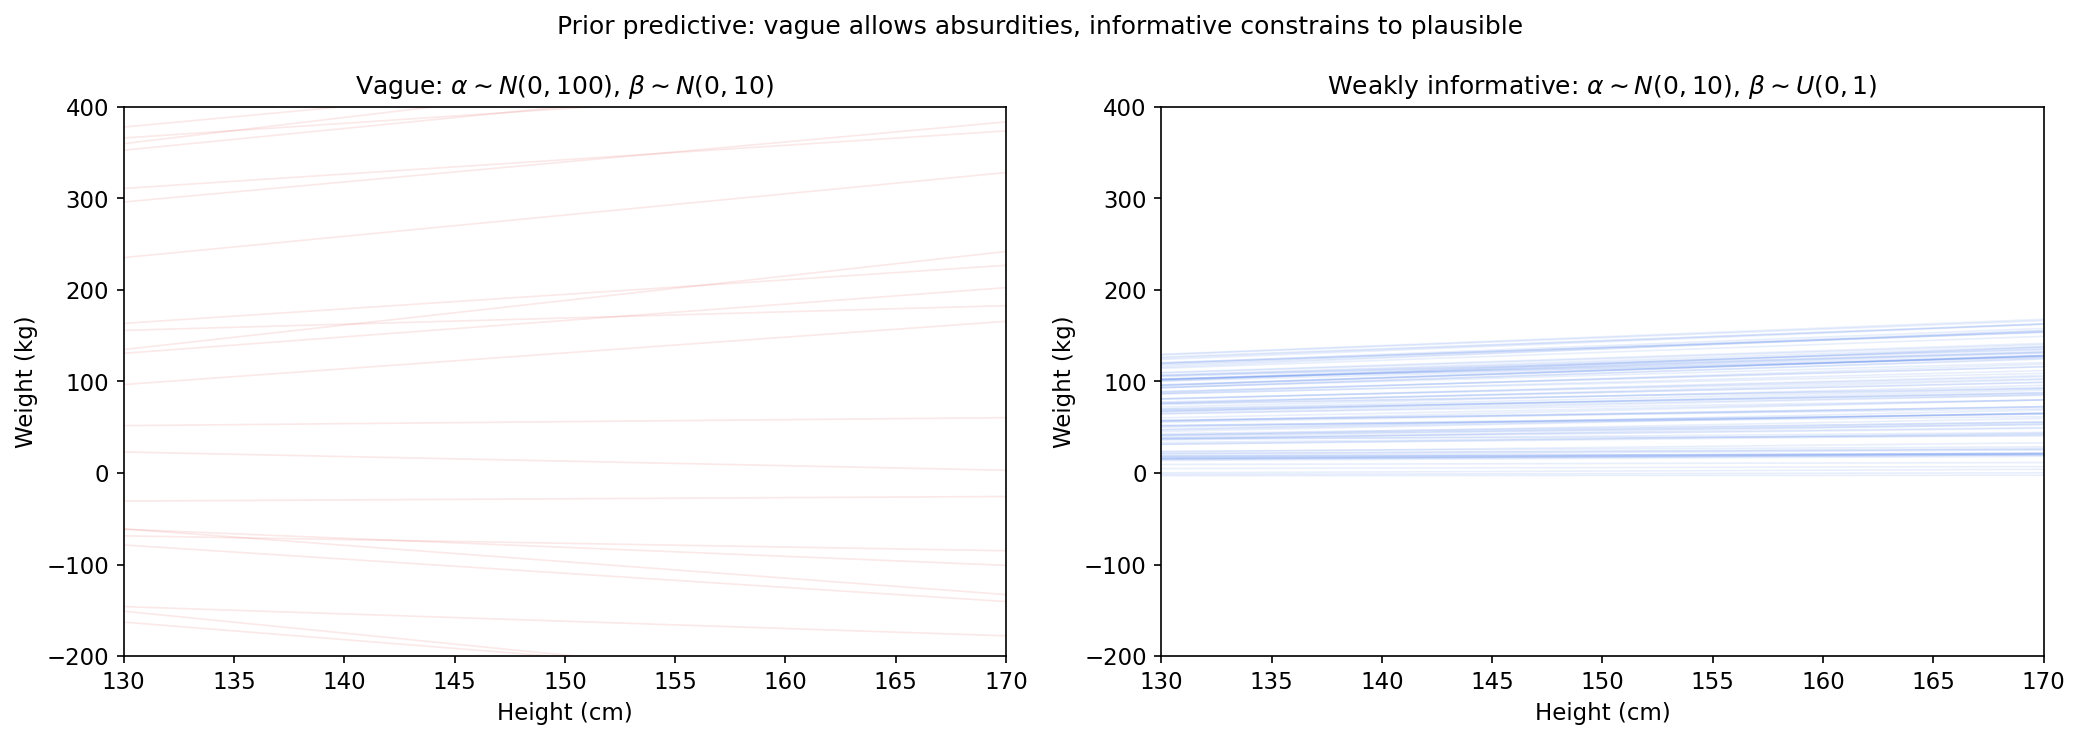

In [5]:
def compare_priors(n_lines: int = 100, seed: int = SEED) -> None:
    """Compare vague vs weakly informative prior predictive lines."""
    rng = np.random.default_rng(seed)
    h_range = np.array([130, 170])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Vague priors
    for _ in range(n_lines):
        a = rng.normal(0, 100)
        b = rng.normal(0, 10)
        axes[0].plot(h_range, a + b * h_range, alpha=0.1, color=C_LIKELIHOOD, linewidth=0.8)
    axes[0].set_title(r"Vague: $\alpha \sim N(0,100)$, $\beta \sim N(0,10)$")
    axes[0].set_xlabel("Height (cm)")
    axes[0].set_ylabel("Weight (kg)")
    axes[0].set_xlim(130, 170)
    axes[0].set_ylim(-200, 400)

    # Weakly informative
    for _ in range(n_lines):
        a = rng.normal(0, 10)
        b = rng.uniform(0, 1)
        axes[1].plot(h_range, a + b * h_range, alpha=0.1, color=C_POSTERIOR, linewidth=0.8)
    axes[1].set_title(r"Weakly informative: $\alpha \sim N(0,10)$, $\beta \sim U(0,1)$")
    axes[1].set_xlabel("Height (cm)")
    axes[1].set_ylabel("Weight (kg)")
    axes[1].set_xlim(130, 170)
    axes[1].set_ylim(-200, 400)

    plt.suptitle("Prior predictive: vague allows absurdities, informative constrains to plausible", fontsize=12)
    plt.tight_layout()
    plt.show()

compare_priors()

## 5. Bayesian Updating: Lines Concentrate as Data Accumulates

Add data points sequentially. With $N=1$, many lines are plausible. With $N=20$, the posterior concentrates to a tight bundle. Same logic as A01/A02 sequential updating, now in three dimensions.

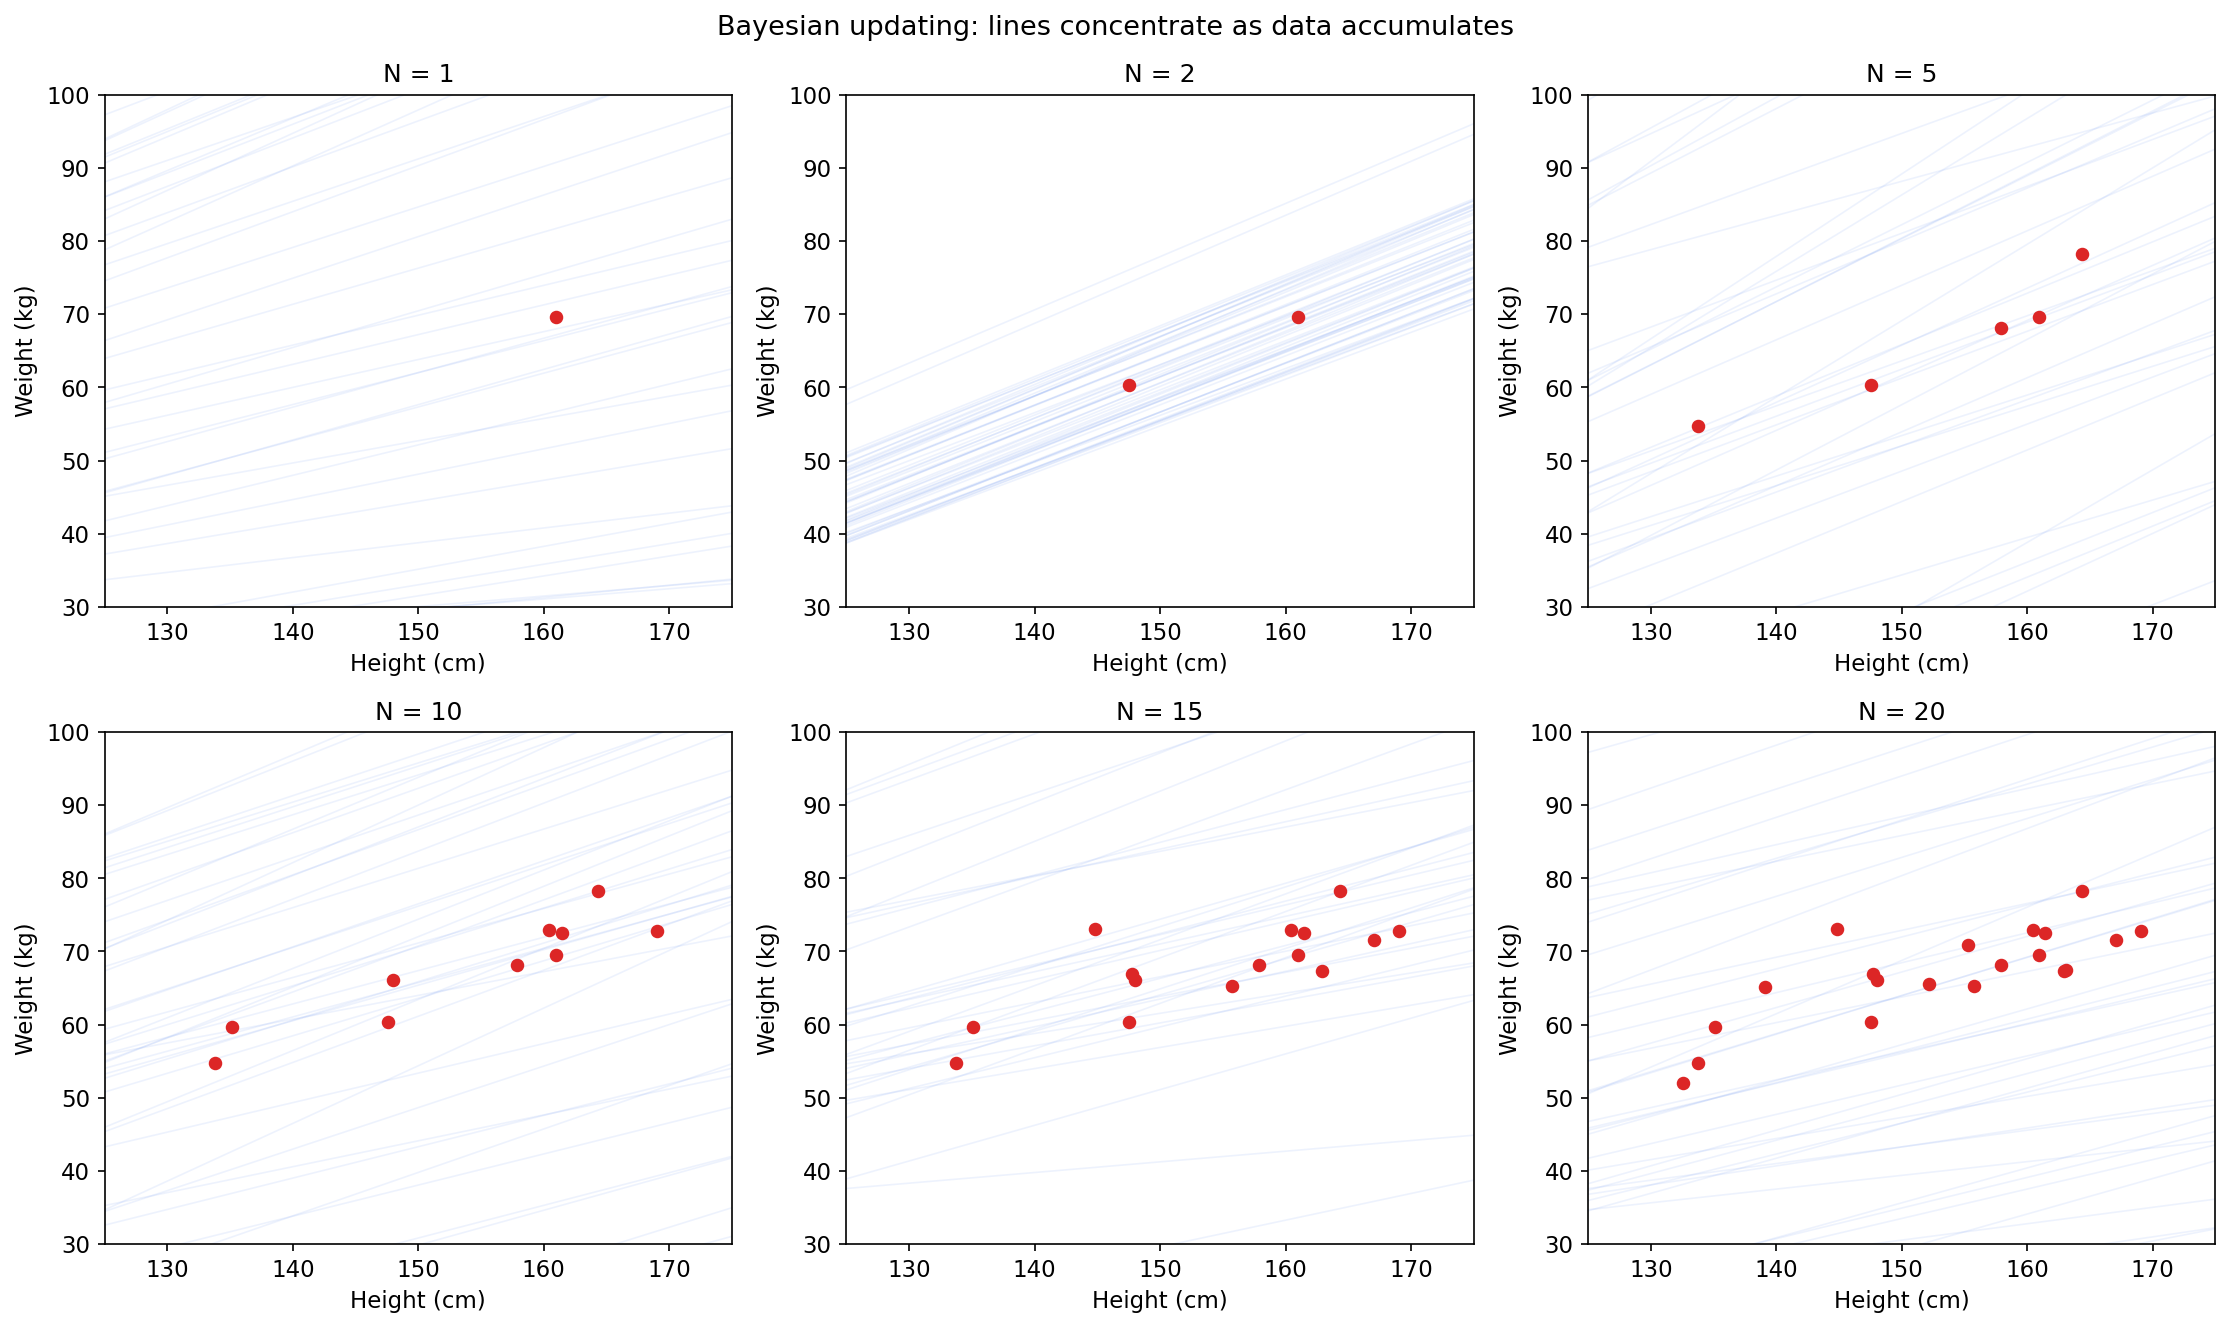

In [6]:
def bayesian_updating_regression(seed: int = SEED) -> None:
    """Show how posterior lines concentrate as data accumulates."""
    rng = np.random.default_rng(seed)

    true_alpha, true_beta, true_sigma = -10.0, 0.5, 5.0
    n = 20
    h = rng.uniform(130, 170, size=n)
    w = true_alpha + true_beta * h + rng.normal(0, true_sigma, size=n)

    h_plot = np.linspace(125, 175, 100)
    n_lines = 50

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()
    data_sizes = [1, 2, 5, 10, 15, 20]

    for ax, n_obs in zip(axes, data_sizes):
        h_obs, w_obs = h[:n_obs], w[:n_obs]

        if n_obs >= 2:
            coeffs = np.polyfit(h_obs, w_obs, 1)
            residuals = w_obs - np.polyval(coeffs, h_obs)
            se_beta = max(np.std(residuals), 0.1) / max(np.sqrt(np.sum((h_obs - h_obs.mean())**2)), 0.1)
            se_alpha = se_beta * np.sqrt(np.mean(h_obs**2))

            for _ in range(n_lines):
                b = rng.normal(coeffs[0], se_beta * 2)
                a = rng.normal(coeffs[1], se_alpha * 2)
                ax.plot(h_plot, a + b * h_plot, alpha=0.08, color=C_POSTERIOR, linewidth=0.8)
        else:
            for _ in range(n_lines):
                a = rng.normal(0, 10)
                b = rng.uniform(0, 1)
                ax.plot(h_plot, a + b * h_plot, alpha=0.08, color=C_POSTERIOR, linewidth=0.8)

        ax.scatter(h_obs, w_obs, color=C_LIKELIHOOD, s=30, zorder=5)
        ax.set_xlim(125, 175)
        ax.set_ylim(30, 100)
        ax.set_title(f"N = {n_obs}")
        ax.set_xlabel("Height (cm)")
        ax.set_ylabel("Weight (kg)")

    plt.suptitle("Bayesian updating: lines concentrate as data accumulates", fontsize=13)
    plt.tight_layout()
    plt.show()

bayesian_updating_regression()

## 6. Quadratic Approximation (Laplace Approximation)

Assume the posterior is approximately multivariate Gaussian. Find the mode (peak), estimate curvature via the Hessian. Mode = MAP estimate. Curvature = covariance matrix.

With flat priors, this equals maximum likelihood estimation. With informative priors, it adds a regularization term.

In [7]:
def quadratic_approximation(
    heights: np.ndarray,
    weights: np.ndarray,
) -> dict:
    """Fit linear regression via quadratic (Laplace) approximation.

    Args:
        heights: Observed heights.
        weights: Observed weights.

    Returns:
        Dict with 'mode' (parameter dict) and 'cov' (3x3 covariance matrix).
    """
    def neg_log_posterior(params: np.ndarray) -> float:
        alpha, beta, log_sigma = params
        sigma = np.exp(log_sigma)
        mu = alpha + beta * heights
        ll = np.sum(stats.norm.logpdf(weights, loc=mu, scale=sigma))
        lp = (
            stats.norm.logpdf(alpha, 0, 10)
            + stats.uniform.logpdf(beta, 0, 1)
            + stats.uniform.logpdf(sigma, 0, 10)
            + log_sigma  # Jacobian for log transform
        )
        return -(ll + lp)

    x0 = np.array([0.0, 0.5, np.log(5.0)])
    result = optimize.minimize(neg_log_posterior, x0, method="Nelder-Mead")

    # Numerical Hessian for covariance
    eps = 1e-5
    hess = np.zeros((3, 3))
    for i in range(3):
        def grad_i(x, _i=i):
            return optimize.approx_fprime(x, neg_log_posterior, eps)[_i]
        hess[i] = optimize.approx_fprime(result.x, grad_i, eps)

    cov = np.linalg.inv(hess)

    mode = result.x.copy()
    mode[2] = np.exp(mode[2])  # log_sigma -> sigma

    return {
        "mode": {"alpha": mode[0], "beta": mode[1], "sigma": mode[2]},
        "cov": cov,
        "raw_mode": result.x,
    }


# Fit to simulated data
fit = quadratic_approximation(h_sim, w_sim)
print("Quadratic approximation (simulated data):")
print(f"  alpha = {fit['mode']['alpha']:.2f}  (true: -10.0 via beta*0 + alpha)")
print(f"  beta  = {fit['mode']['beta']:.4f}  (true: 0.500)")
print(f"  sigma = {fit['mode']['sigma']:.2f}  (true: 5.00)")
print(f"\nCovariance matrix (in log-sigma space):")
print(np.array2string(fit['cov'], precision=4, suppress_small=True))

Quadratic approximation (simulated data):
  alpha = 0.00  (true: -10.0 via beta*0 + alpha)
  beta  = 0.4991  (true: 0.500)
  sigma = 4.41  (true: 5.00)

Covariance matrix (in log-sigma space):
[[14.8337 -0.0985  0.0118]
 [-0.0985  0.0007 -0.0001]
 [ 0.0118 -0.0001  0.0025]]


## 7. Posterior Samples and Posterior Predictive

Sample from the quadratic approximation (multivariate normal), transform back to parameter space, push through generative model for predictions.

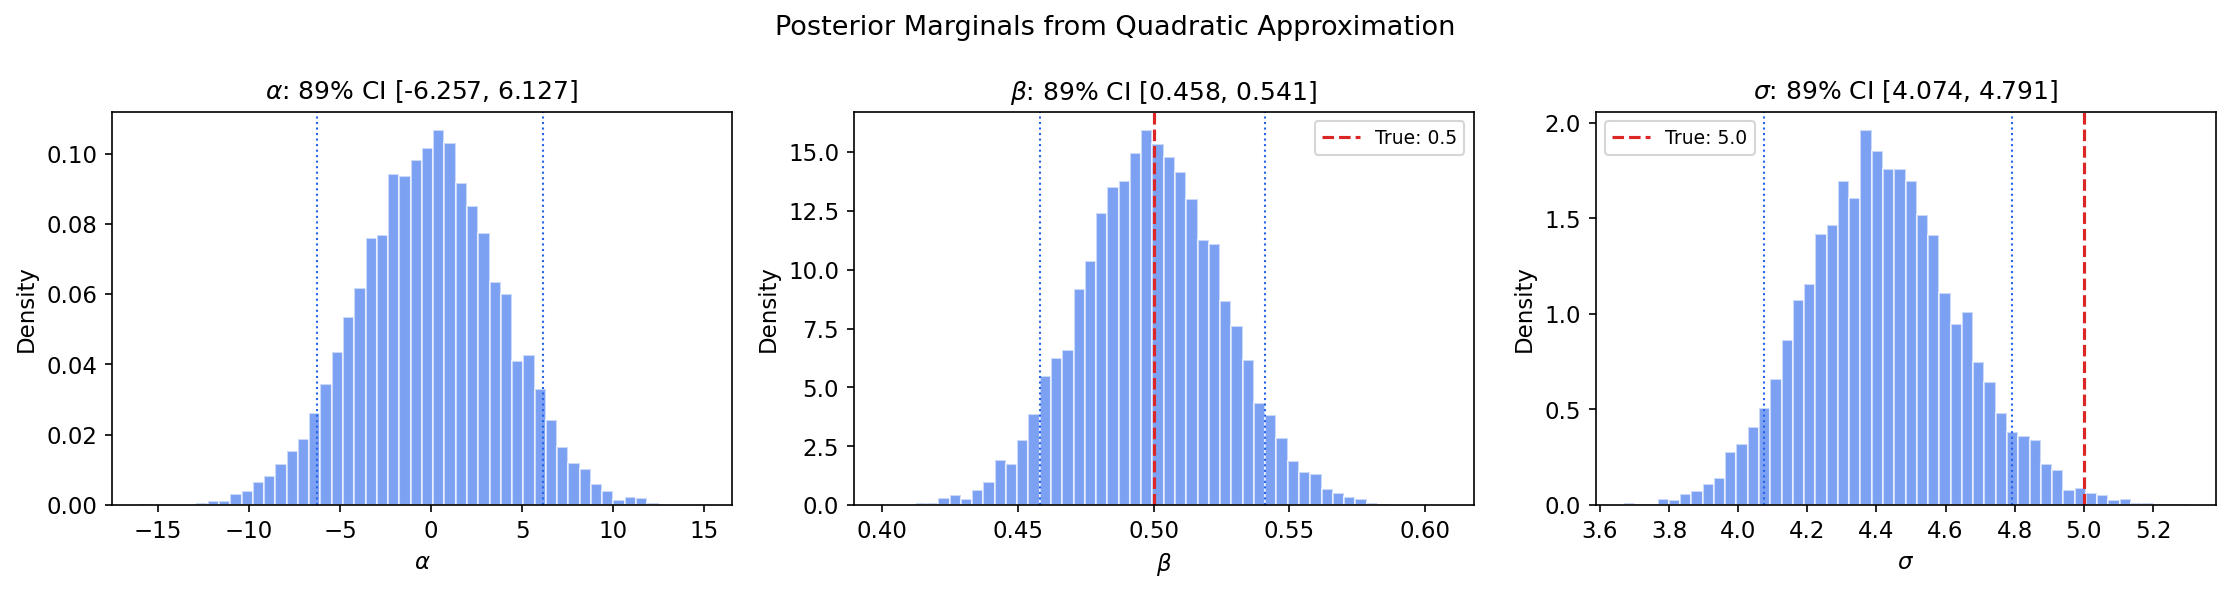

In [8]:
# Draw samples from the approximate posterior
rng_post = np.random.default_rng(SEED)
samples_raw = rng_post.multivariate_normal(fit['raw_mode'], fit['cov'], size=N_SAMPLES)

alpha_samples = samples_raw[:, 0]
beta_samples = samples_raw[:, 1]
sigma_samples = np.exp(samples_raw[:, 2])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, samp, name, true_val in zip(
    axes,
    [alpha_samples, beta_samples, sigma_samples],
    [r"$\alpha$", r"$\beta$", r"$\sigma$"],
    [None, 0.5, 5.0],
):
    ax.hist(samp, bins=50, density=True, alpha=0.6, color=C_POSTERIOR, edgecolor="white")
    ci_lo, ci_hi = np.percentile(samp, 5.5), np.percentile(samp, 94.5)
    ax.axvline(ci_lo, color=C_POSTERIOR, linestyle=":", linewidth=1)
    ax.axvline(ci_hi, color=C_POSTERIOR, linestyle=":", linewidth=1)
    if true_val is not None:
        ax.axvline(true_val, color=C_LIKELIHOOD, linestyle="--", linewidth=1.5, label=f"True: {true_val}")
        ax.legend(fontsize=9)
    ax.set_title(f"{name}: 89% CI [{ci_lo:.3f}, {ci_hi:.3f}]")
    ax.set_xlabel(name)
    ax.set_ylabel("Density")

plt.suptitle("Posterior Marginals from Quadratic Approximation", fontsize=13)
plt.tight_layout()
plt.show()

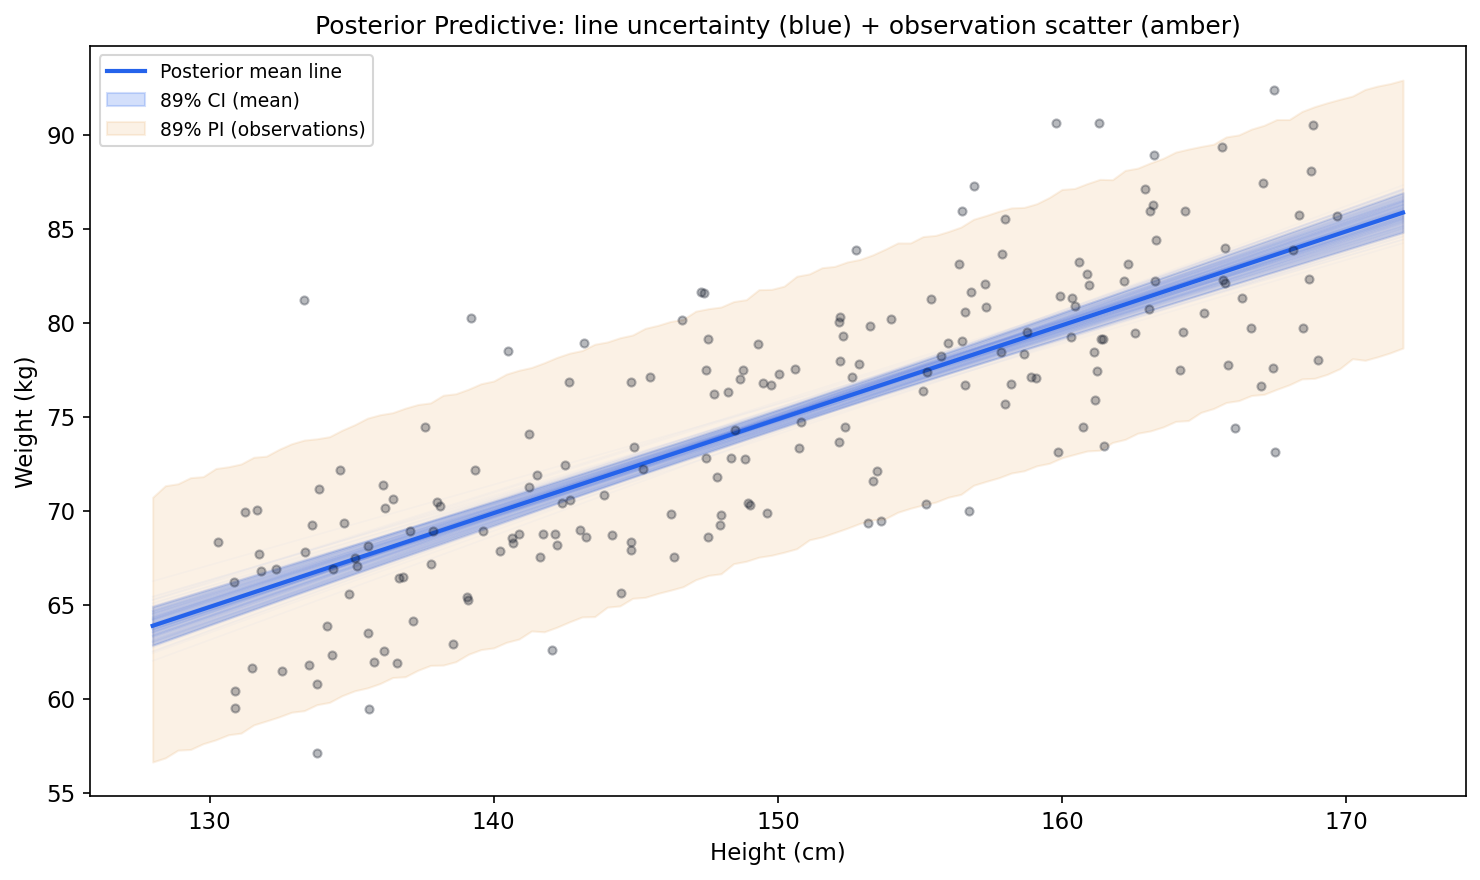

In [9]:
# Posterior predictive: regression line uncertainty + observation scatter
h_pred = np.linspace(128, 172, 100)

fig, ax = plt.subplots(figsize=(10, 6))

# Sample 200 lines from posterior
for i in range(200):
    mu_line = alpha_samples[i] + beta_samples[i] * h_pred
    ax.plot(h_pred, mu_line, alpha=0.02, color=C_POSTERIOR, linewidth=0.8)

# Mean line
mu_mean = alpha_samples.mean() + beta_samples.mean() * h_pred
ax.plot(h_pred, mu_mean, color=C_POSTERIOR, linewidth=2, label="Posterior mean line")

# 89% CI for mu
mu_all = alpha_samples[:, None] + beta_samples[:, None] * h_pred[None, :]
mu_lo = np.percentile(mu_all, 5.5, axis=0)
mu_hi = np.percentile(mu_all, 94.5, axis=0)
ax.fill_between(h_pred, mu_lo, mu_hi, alpha=0.2, color=C_POSTERIOR, label="89% CI (mean)")

# 89% prediction interval (includes sigma)
pred_all = mu_all + rng_post.normal(0, sigma_samples[:, None], size=mu_all.shape)
pred_lo = np.percentile(pred_all, 5.5, axis=0)
pred_hi = np.percentile(pred_all, 94.5, axis=0)
ax.fill_between(h_pred, pred_lo, pred_hi, alpha=0.1, color=C_ACCENT, label="89% PI (observations)")

ax.scatter(h_sim, w_sim, alpha=0.3, s=15, color=C_POINT, zorder=5)
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Weight (kg)")
ax.set_title("Posterior Predictive: line uncertainty (blue) + observation scatter (amber)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---

# Part 2: Applied Exercises with Slovenian Data

The same linear regression workflow from Part 1, applied to real datasets. All exercises scope to recent years (2022+) to avoid mixing structurally different market regimes.

In [10]:
# Load datasets
re = pd.read_csv(DATA_DIR / "sr2026_real_estate.csv", parse_dates=["date"])
forensic = pd.read_csv(DATA_DIR / "sr2026_forensic_audio.csv")
mun = pd.read_csv(DATA_DIR / "sr2026_municipality_panel.csv")

# Scope real estate to recent years, Ljubljana apartments
YEAR_MIN = 2022
lj_apt = re[
    (re["municipality"] == "LJUBLJANA")
    & (re["property_type"] == "apartment")
    & (re["price_per_m2"].notna())
    & (re["area_m2"].notna())
    & (re["year"] >= YEAR_MIN)
    & (re["area_m2"] > 10) & (re["area_m2"] < 200)
    & (re["price_eur"] > 5_000) & (re["price_eur"] < 500_000)
].copy()

print(f"Ljubljana apartments ({YEAR_MIN}+): {len(lj_apt):,} transactions")
print(f"Area range: {lj_apt['area_m2'].min():.0f} - {lj_apt['area_m2'].max():.0f} m2")
print(f"Price range: {lj_apt['price_eur'].min():,.0f} - {lj_apt['price_eur'].max():,.0f} EUR")

Ljubljana apartments (2022+): 3,566 transactions
Area range: 13 - 198 m2
Price range: 10,000 - 499,738 EUR


## Exercise 1: Area → Price Linear Model for Ljubljana Apartments

**DAG:** $\text{Area} \rightarrow \text{Price} \leftarrow U$

**Estimand:** How does floor area influence transaction price? Expected change in EUR per additional m2.

**Scientific model:** More space = higher price. The relationship is approximately linear for typical apartment sizes (20-150 m2). Unobserved factors (floor, renovation, view) add Gaussian scatter.

$$\text{Price}_i \sim \text{Normal}(\mu_i, \sigma)$$
$$\mu_i = \alpha + \beta \cdot \text{Area}_i$$
$$\alpha \sim \text{Normal}(0, 50{,}000) \quad \text{(base price, wide)}$$
$$\beta \sim \text{Normal}(3000, 1000) \quad \text{(~3K EUR/m2, domain knowledge)}$$
$$\sigma \sim \text{Uniform}(0, 100{,}000)$$

In [11]:
# Quadratic approximation for Ljubljana area -> price
def quap_area_price(areas: np.ndarray, prices: np.ndarray) -> dict:
    """Fit area -> price linear model via quadratic approximation."""
    def neg_lp(params):
        alpha, beta, log_sigma = params
        sigma = np.exp(log_sigma)
        mu = alpha + beta * areas
        ll = np.sum(stats.norm.logpdf(prices, loc=mu, scale=sigma))
        lp = (
            stats.norm.logpdf(alpha, 0, 50_000)
            + stats.norm.logpdf(beta, 3000, 1000)
            + log_sigma  # Jacobian
        )
        if sigma <= 0 or sigma > 100_000:
            return 1e12
        return -(ll + lp)

    x0 = np.array([10_000, 3000, np.log(30_000)])
    result = optimize.minimize(neg_lp, x0, method="Nelder-Mead",
                               options={"maxiter": 10_000})

    eps = 1e-5
    hess = np.zeros((3, 3))
    for i in range(3):
        def grad_i(x, _i=i):
            return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(result.x, grad_i, eps)

    cov = np.linalg.inv(hess)
    mode = result.x.copy()
    mode[2] = np.exp(mode[2])

    return {"mode": {"alpha": mode[0], "beta": mode[1], "sigma": mode[2]},
            "cov": cov, "raw_mode": result.x}


fit_re = quap_area_price(lj_apt["area_m2"].values, lj_apt["price_eur"].values)
print("Quadratic approximation: Ljubljana area -> price")
print(f"  alpha (base price) = {fit_re['mode']['alpha']:,.0f} EUR")
print(f"  beta (EUR per m2)  = {fit_re['mode']['beta']:,.0f} EUR/m2")
print(f"  sigma              = {fit_re['mode']['sigma']:,.0f} EUR")

Quadratic approximation: Ljubljana area -> price
  alpha (base price) = 71,208 EUR
  beta (EUR per m2)  = 2,197 EUR/m2
  sigma              = 56,277 EUR


/tmp/ipykernel_1869392/46569923.py:3: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samp_raw = rng_re.multivariate_normal(fit_re['raw_mode'], fit_re['cov'], size=N_SAMPLES)


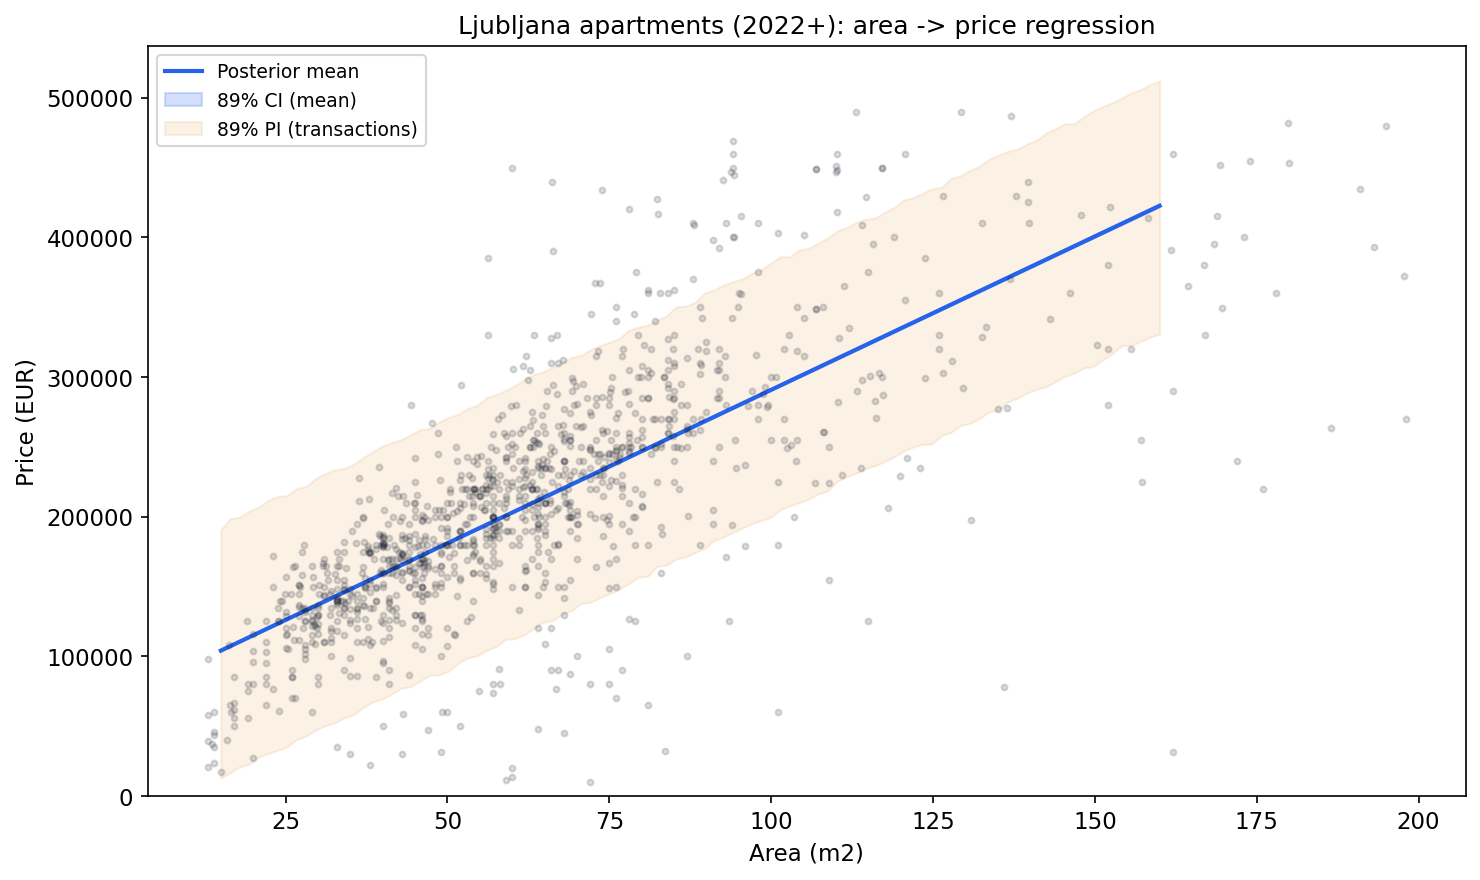

Each additional m2 adds ~2,197 EUR [2,193, 2,201]


In [12]:
# Posterior predictive: area -> price
rng_re = np.random.default_rng(SEED)
samp_raw = rng_re.multivariate_normal(fit_re['raw_mode'], fit_re['cov'], size=N_SAMPLES)
a_samp = samp_raw[:, 0]
b_samp = samp_raw[:, 1]
s_samp = np.exp(samp_raw[:, 2])

area_pred = np.linspace(15, 160, 100)

fig, ax = plt.subplots(figsize=(10, 6))

# Sample lines
for i in range(200):
    ax.plot(area_pred, a_samp[i] + b_samp[i] * area_pred,
            alpha=0.02, color=C_POSTERIOR, linewidth=0.8)

# Mean line
mu_mean_re = a_samp.mean() + b_samp.mean() * area_pred
ax.plot(area_pred, mu_mean_re, color=C_POSTERIOR, linewidth=2, label="Posterior mean")

# 89% CI for mu
mu_all_re = a_samp[:, None] + b_samp[:, None] * area_pred[None, :]
mu_lo = np.percentile(mu_all_re, 5.5, axis=0)
mu_hi = np.percentile(mu_all_re, 94.5, axis=0)
ax.fill_between(area_pred, mu_lo, mu_hi, alpha=0.2, color=C_POSTERIOR, label="89% CI (mean)")

# 89% PI
pred_re = mu_all_re + rng_re.normal(0, s_samp[:, None], size=mu_all_re.shape)
ax.fill_between(area_pred, np.percentile(pred_re, 5.5, axis=0),
                np.percentile(pred_re, 94.5, axis=0),
                alpha=0.1, color=C_ACCENT, label="89% PI (transactions)")

# Data subsample for visibility
ax.scatter(lj_apt["area_m2"].values[::3], lj_apt["price_eur"].values[::3],
           alpha=0.15, s=8, color=C_POINT, zorder=5)

ax.set_xlabel("Area (m2)")
ax.set_ylabel("Price (EUR)")
ax.set_title(f"Ljubljana apartments ({YEAR_MIN}+): area -> price regression")
ax.legend(fontsize=9)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

print(f"Each additional m2 adds ~{b_samp.mean():,.0f} EUR [{np.percentile(b_samp, 5.5):,.0f}, {np.percentile(b_samp, 94.5):,.0f}]")

## Exercise 2: Forensic Audio — Duration → Anomaly Count

**DAG:** $\text{Duration} \rightarrow \text{Anomalies} \leftarrow U$

**Estimand:** Does recording duration predict the number of splice candidate detections? For authentic recordings, anomalies should scale linearly with duration (constant false-positive rate). A splice breaks this linearity.

**Note:** This is a Gaussian approximation to what should be a Poisson/count model. Acceptable for illustration; later lectures introduce proper count models.

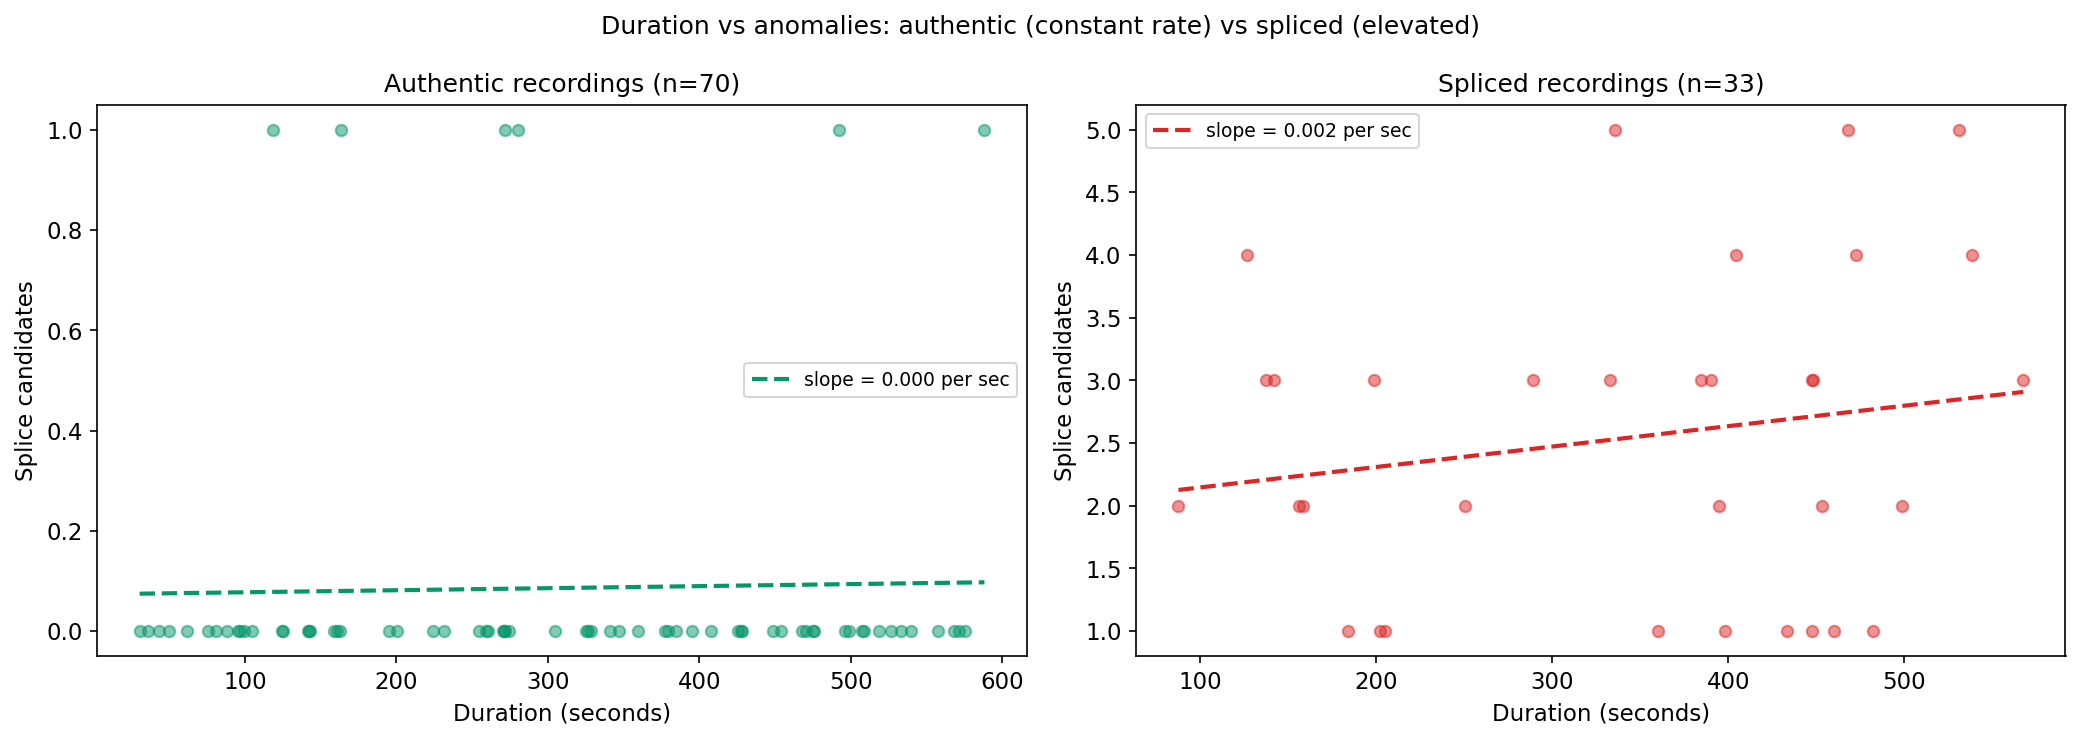

In [13]:
# Duration vs splice_candidates for authentic vs manipulated recordings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cat, color, label) in zip(axes, [
    ("authentic", C_DATA, "Authentic"),
    ("spliced", C_LIKELIHOOD, "Spliced"),
]):
    subset = forensic[forensic["category"] == cat]
    if len(subset) < 5:
        ax.set_title(f"{label}: too few observations")
        continue

    ax.scatter(subset["duration_s"], subset["splice_candidates"],
               alpha=0.5, s=30, color=color)

    # Fit quick regression
    x, y = subset["duration_s"].values, subset["splice_candidates"].values
    if len(x) >= 3:
        coeffs = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 50)
        ax.plot(x_line, np.polyval(coeffs, x_line), color=color, linewidth=2,
                linestyle="--", label=f"slope = {coeffs[0]:.3f} per sec")

    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Splice candidates")
    ax.set_title(f"{label} recordings (n={len(subset)})")
    ax.legend(fontsize=9)

plt.suptitle("Duration vs anomalies: authentic (constant rate) vs spliced (elevated)", fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
# Quadratic approximation: duration -> splice_candidates (authentic only)
auth = forensic[forensic["category"] == "authentic"].copy()
dur = auth["duration_s"].values
spl = auth["splice_candidates"].values.astype(float)

def quap_forensic(durations, counts):
    """Fit duration -> anomaly count for authentic recordings."""
    def neg_lp(params):
        alpha, beta, log_sigma = params
        sigma = np.exp(log_sigma)
        mu = alpha + beta * durations
        ll = np.sum(stats.norm.logpdf(counts, loc=mu, scale=sigma))
        lp = (
            stats.norm.logpdf(alpha, 0, 5)
            + stats.norm.logpdf(beta, 0.01, 0.02)
            + log_sigma
        )
        if sigma <= 0:
            return 1e12
        return -(ll + lp)

    x0 = np.array([0.0, 0.01, np.log(1.0)])
    result = optimize.minimize(neg_lp, x0, method="Nelder-Mead", options={"maxiter": 10_000})

    eps = 1e-5
    hess = np.zeros((3, 3))
    for i in range(3):
        def grad_i(x, _i=i):
            return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(result.x, grad_i, eps)

    cov = np.linalg.inv(hess)
    mode = result.x.copy()
    mode[2] = np.exp(mode[2])
    return {"mode": {"alpha": mode[0], "beta": mode[1], "sigma": mode[2]},
            "cov": cov, "raw_mode": result.x}

fit_for = quap_forensic(dur, spl)
print("Authentic recordings: duration -> splice candidates")
print(f"  alpha (baseline)   = {fit_for['mode']['alpha']:.3f}")
print(f"  beta (per second)  = {fit_for['mode']['beta']:.4f}")
print(f"  sigma              = {fit_for['mode']['sigma']:.3f}")
print(f"\nA 60-second authentic recording: ~{fit_for['mode']['alpha'] + fit_for['mode']['beta']*60:.1f} expected splice candidates")

Authentic recordings: duration -> splice candidates
  alpha (baseline)   = 0.073
  beta (per second)  = 0.0000
  sigma              = 0.282

A 60-second authentic recording: ~0.1 expected splice candidates


## Exercise 3: Prior Predictive Check — Domain-Informed Priors for Real Estate

**Demonstration of vague vs domain-informed priors for the area-price model.**

Vague: $\beta \sim \text{Normal}(0, 100{,}000)$ — allows negative prices, 100K EUR/m2, absurdities.

Domain-informed: $\beta \sim \text{Normal}(3000, 1000)$ — centered on Slovenian market knowledge, still flexible.

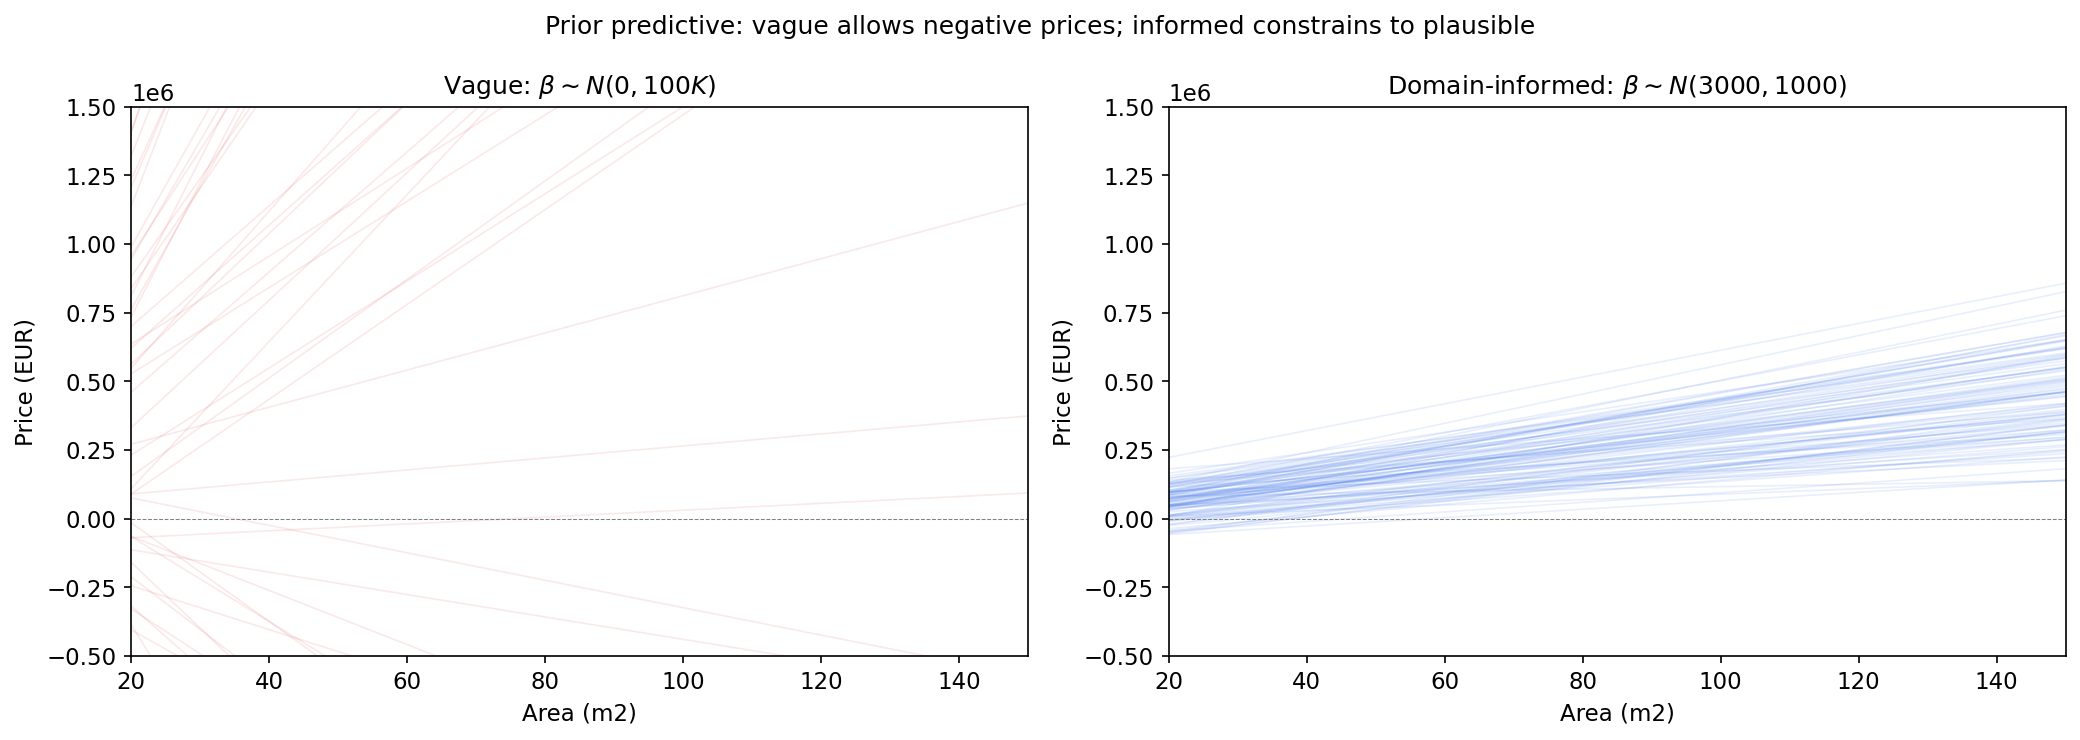

The domain-informed prior encodes: ~3K EUR/m2 for Slovenian apartments.
It does not force this value — the data can override it — but it prevents absurdities.


In [15]:
# Prior predictive: vague vs domain-informed for area -> price
rng_pp = np.random.default_rng(SEED)
n_lines = 100
area_range = np.array([20, 150])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vague priors
ax = axes[0]
for _ in range(n_lines):
    a = rng_pp.normal(0, 200_000)
    b = rng_pp.normal(0, 100_000)
    ax.plot(area_range, a + b * area_range, alpha=0.1, color=C_LIKELIHOOD, linewidth=0.8)
ax.set_title(r"Vague: $\beta \sim N(0, 100K)$")
ax.set_xlabel("Area (m2)")
ax.set_ylabel("Price (EUR)")
ax.set_xlim(20, 150)
ax.set_ylim(-500_000, 1_500_000)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

# Domain-informed
ax = axes[1]
for _ in range(n_lines):
    a = rng_pp.normal(0, 50_000)
    b = rng_pp.normal(3000, 1000)
    ax.plot(area_range, a + b * area_range, alpha=0.1, color=C_POSTERIOR, linewidth=0.8)
ax.set_title(r"Domain-informed: $\beta \sim N(3000, 1000)$")
ax.set_xlabel("Area (m2)")
ax.set_ylabel("Price (EUR)")
ax.set_xlim(20, 150)
ax.set_ylim(-500_000, 1_500_000)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

plt.suptitle("Prior predictive: vague allows negative prices; informed constrains to plausible", fontsize=12)
plt.tight_layout()
plt.show()

print("The domain-informed prior encodes: ~3K EUR/m2 for Slovenian apartments.")
print("It does not force this value — the data can override it — but it prevents absurdities.")

## Exercise 4: Municipality Panel — Salary → Median Price

**DAG:** $\text{Salary} \rightarrow \text{Price} \leftarrow U$

**Estimand:** How does average gross salary predict median residential price per m2 across municipalities?

**Scientific model:** Higher-salary municipalities attract more demand, pushing prices up. The relationship is approximately linear in cross-section. Unobserved factors (location, amenities, supply constraints) add scatter.

In [16]:
# Salary -> median price regression across municipalities
latest_year = mun["year"].max()
mun_latest = mun[
    (mun["year"] == latest_year)
    & mun["avg_gross_salary"].notna()
    & mun["median_price_m2"].notna()
].copy()

sal = mun_latest["avg_gross_salary"].values
price_m2 = mun_latest["median_price_m2"].values

print(f"Municipalities ({latest_year}): {len(mun_latest)}")
print(f"Salary range: {sal.min():,.0f} - {sal.max():,.0f} EUR/month")
print(f"Median price/m2 range: {price_m2.min():,.0f} - {price_m2.max():,.0f} EUR")

Municipalities (2024): 183
Salary range: 1,752 - 2,892 EUR/month
Median price/m2 range: 125 - 3,761 EUR


In [17]:
# Fit quadratic approximation
def quap_salary_price(salaries, prices):
    """Fit salary -> price/m2 regression."""
    def neg_lp(params):
        alpha, beta, log_sigma = params
        sigma = np.exp(log_sigma)
        mu = alpha + beta * salaries
        ll = np.sum(stats.norm.logpdf(prices, loc=mu, scale=sigma))
        lp = (
            stats.norm.logpdf(alpha, 0, 2000)
            + stats.norm.logpdf(beta, 0.5, 0.5)
            + log_sigma
        )
        if sigma <= 0:
            return 1e12
        return -(ll + lp)

    x0 = np.array([0.0, 0.5, np.log(300)])
    result = optimize.minimize(neg_lp, x0, method="Nelder-Mead", options={"maxiter": 10_000})

    eps = 1e-5
    hess = np.zeros((3, 3))
    for i in range(3):
        def grad_i(x, _i=i):
            return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(result.x, grad_i, eps)

    cov = np.linalg.inv(hess)
    mode = result.x.copy()
    mode[2] = np.exp(mode[2])
    return {"mode": {"alpha": mode[0], "beta": mode[1], "sigma": mode[2]},
            "cov": cov, "raw_mode": result.x}

fit_mun = quap_salary_price(sal, price_m2)
print(f"Salary -> price/m2 regression ({latest_year}):")
print(f"  alpha = {fit_mun['mode']['alpha']:,.0f} EUR/m2")
print(f"  beta  = {fit_mun['mode']['beta']:.2f} EUR/m2 per EUR salary")
print(f"  sigma = {fit_mun['mode']['sigma']:,.0f} EUR/m2")
print(f"\nInterpretation: each additional EUR/month in avg salary")
print(f"  predicts {fit_mun['mode']['beta']:.2f} EUR/m2 higher median price")

Salary -> price/m2 regression (2024):
  alpha = -0 EUR/m2
  beta  = 0.66 EUR/m2 per EUR salary
  sigma = 711 EUR/m2

Interpretation: each additional EUR/month in avg salary
  predicts 0.66 EUR/m2 higher median price


/tmp/ipykernel_1869392/1960781293.py:3: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samp_mun = rng_mun.multivariate_normal(fit_mun['raw_mode'], fit_mun['cov'], size=N_SAMPLES)


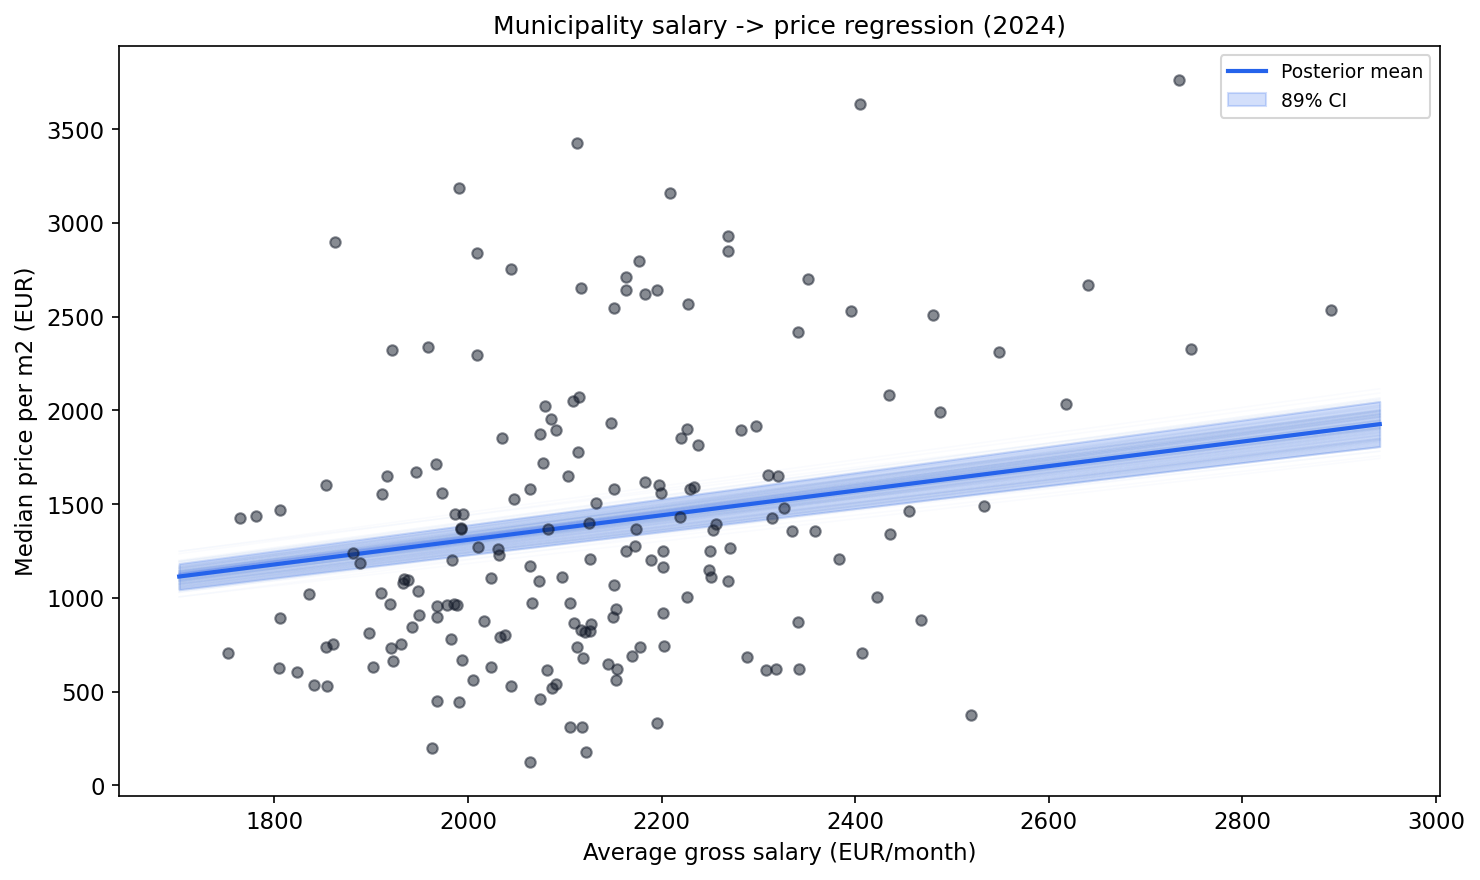

In [18]:
# Posterior predictive plot
rng_mun = np.random.default_rng(SEED)
samp_mun = rng_mun.multivariate_normal(fit_mun['raw_mode'], fit_mun['cov'], size=N_SAMPLES)
a_m = samp_mun[:, 0]
b_m = samp_mun[:, 1]
s_m = np.exp(samp_mun[:, 2])

sal_pred = np.linspace(sal.min() - 50, sal.max() + 50, 100)

fig, ax = plt.subplots(figsize=(10, 6))

# Sample lines
for i in range(200):
    ax.plot(sal_pred, a_m[i] + b_m[i] * sal_pred,
            alpha=0.02, color=C_POSTERIOR, linewidth=0.8)

# Mean + CI
mu_mun = a_m[:, None] + b_m[:, None] * sal_pred[None, :]
ax.plot(sal_pred, mu_mun.mean(axis=0), color=C_POSTERIOR, linewidth=2, label="Posterior mean")
ax.fill_between(sal_pred, np.percentile(mu_mun, 5.5, axis=0),
                np.percentile(mu_mun, 94.5, axis=0),
                alpha=0.2, color=C_POSTERIOR, label="89% CI")

# Data
ax.scatter(sal, price_m2, alpha=0.5, s=25, color=C_POINT, zorder=5)

ax.set_xlabel("Average gross salary (EUR/month)")
ax.set_ylabel("Median price per m2 (EUR)")
ax.set_title(f"Municipality salary -> price regression ({latest_year})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Exercise 5: Point Estimate vs Full Posterior Predictions

**A03 lesson:** Never plug the posterior mean into the generative model. Use the full posterior for predictions.

Compare predicted price for a 60 m2 Ljubljana apartment using: (a) point estimate, (b) full posterior.

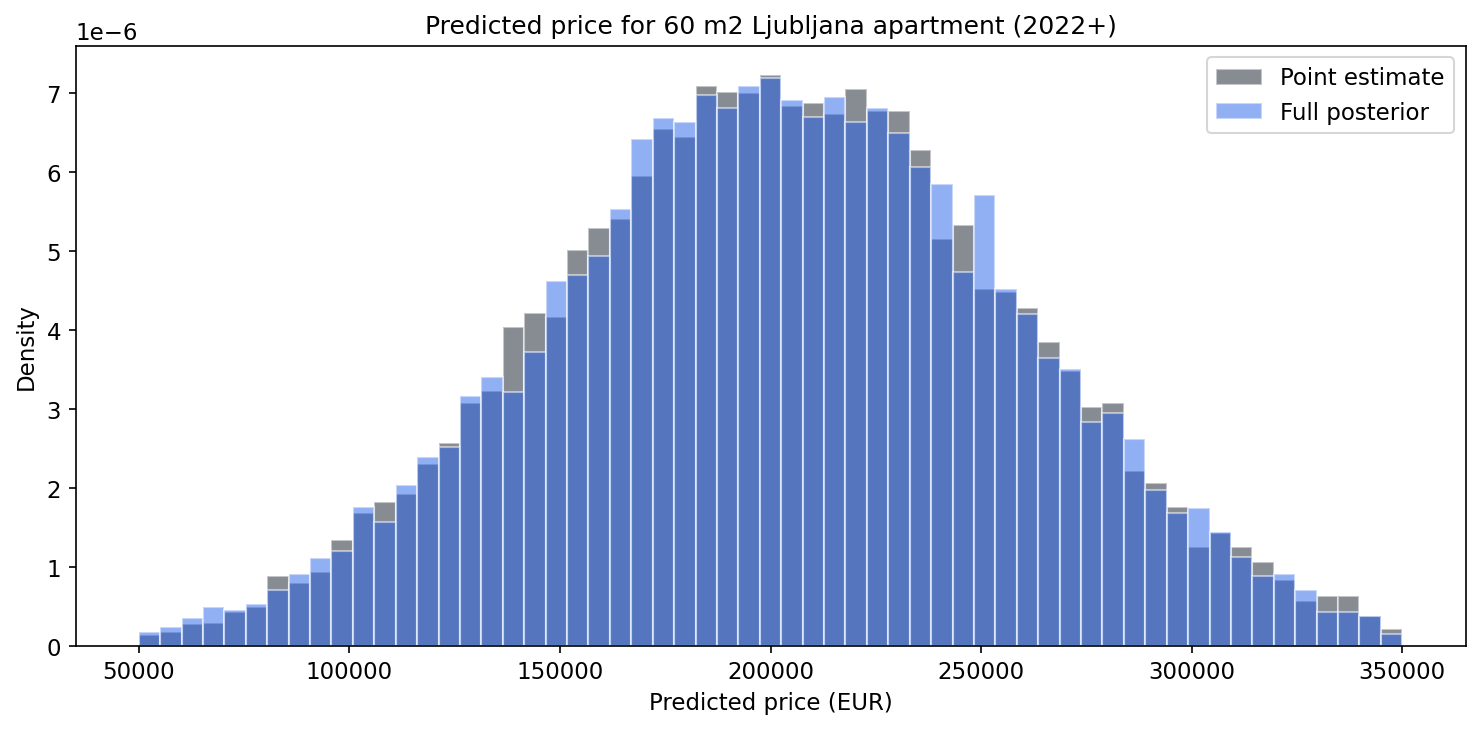

Full posterior:  mean = 203,437 EUR, std = 56,446
Point estimate:  mean = 203,568 EUR, std = 56,396
Full posterior is 1.00x wider — honest uncertainty.


In [19]:
# Predict price for a 60 m2 apartment
TARGET_AREA = 60

# Full posterior predictive
mu_full = a_samp + b_samp * TARGET_AREA
pred_full = mu_full + rng_re.normal(0, s_samp)

# Point estimate
mu_point = fit_re['mode']['alpha'] + fit_re['mode']['beta'] * TARGET_AREA
pred_point = rng_re.normal(mu_point, fit_re['mode']['sigma'], size=N_SAMPLES)

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(50_000, 350_000, 60)

ax.hist(pred_point, bins=bins, density=True, alpha=0.5,
        color=C_POINT, edgecolor="white", label="Point estimate")
ax.hist(pred_full, bins=bins, density=True, alpha=0.5,
        color=C_POSTERIOR, edgecolor="white", label="Full posterior")

ax.set_xlabel("Predicted price (EUR)")
ax.set_ylabel("Density")
ax.set_title(f"Predicted price for {TARGET_AREA} m2 Ljubljana apartment ({YEAR_MIN}+)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Full posterior:  mean = {pred_full.mean():,.0f} EUR, std = {pred_full.std():,.0f}")
print(f"Point estimate:  mean = {pred_point.mean():,.0f} EUR, std = {pred_point.std():,.0f}")
print(f"Full posterior is {pred_full.std() / pred_point.std():.2f}x wider — honest uncertainty.")

---

# Key Takeaways

1. **Linear regression is geocentric.** It describes associations and predicts, but says nothing about mechanism. The DAG provides the why; the regression provides the how much. Area predicts price, but the regression alone cannot tell you whether area *causes* price or both are driven by location.

2. **The garden of forking data scales to any dimension.** One parameter (A01) to three (A03) to hundreds (hierarchical models). The logic is unchanged: count ways, weight by prior, normalize.

3. **Prior predictive simulation catches bad priors.** Vague priors on the area-price slope allow negative prices and 100K EUR/m2. Domain-informed priors ($\beta \sim N(3000, 1000)$) constrain to plausible while letting data override.

4. **Quadratic approximation connects Bayesian and frequentist.** With flat priors, it equals MLE. With informative priors, it adds regularization. Works well for simple regression; breaks for hierarchical models.

5. **Summarize last.** Predicting the price of a 60 m2 apartment with point estimates underestimates uncertainty. The full posterior propagates parameter uncertainty into honest prediction intervals.

6. **Scope data to comparable regimes.** All real estate exercises use 2022+ data. Pooling across 2007-2025 conflates structural market changes with the linear relationship we want to estimate.

**Next:** [[Lecture A04]] fits the model to data, examines posterior distributions, and generates posterior predictive checks.